# Reproducing the analysis pipeline

This notebook reproduces the computational analyses reported in the study. It
loads the configured corpus, runs the analysis pipeline stage by stage, and
writes the resulting tables and figures. The methods live in `pipeline/`; this
notebook decides which step runs on which data, and shows what each produces.

## The pipeline

    configuration
      -> load and prepare the corpus
      -> semantic representation
      -> manifold projection
      -> granularity selection and the canonical partition
      -> lexical characterisation
      -> four complementary diagnostic dimensions
      -> independent second-register reconstruction
      -> cross-register correspondence
      -> matched-event compositional comparison
      -> analytical tables and figures

## Two predefined configurations

`CONFIG = IRACING` runs the redistributable one-register demonstration corpus.
Every single-register stage runs; the three stages that genuinely require a
second register print the reason and are skipped.

`CONFIG = F1` runs the complete two-register Formula 1 workflow. The Formula 1
transcripts are broadcast-copyright and are **not distributed**; they must be
supplied independently at the documented paths (`data/f1_highlights/README.md`,
`data/f1_full/README.md`).

No other line in this notebook needs editing for either configuration.

Nothing is substituted for a missing register. A corpus is never split into
pseudo-registers, never compared against itself, and no synthetic second
register is generated. Naming a corpus that is missing is a configuration error
and stops the run.

A run on the sim-racing corpus is a **code-path reproduction on open data**. It
is not an analytical replication of the Formula 1 results, not an external
validation, and not evidence for the Formula 1 cross-register result.

## Stage 0 — Environment and configuration

In [1]:
from pathlib import Path
import json, sys, time

REL = Path.cwd()                      # the notebook runs from the release root
sys.path.insert(0, str(REL))

from IPython.display import Image
import numpy as np
import pandas as pd
import pipeline as P
from pipeline import frozen_f1 as FROZEN

T0 = time.time()

### Configuration

The two configurations live in `pipeline/config.py`, the single place where a
run is defined. Assign one of them to `CONFIG` and run every cell.

`IRACING` is the redistributable one-register demonstration. `F1` is the
two-register Formula 1 workflow and needs the licensed transcripts in place.
Everything the two objects do not state - encoder, projection, granularity,
enrichment and diagnostic settings - comes from the per-corpus presets and
defaults in the same file, and the next cell prints all of it.

In [2]:
from pipeline.config import IRACING, F1

CONFIG = IRACING          # IRACING or F1

### Resolved settings

Everything below follows from the configuration selected above. These are the
settings that define the reported experiment.

In [3]:
cfg, cfg2 = P.config.resolve_corpora(CONFIG, REL)

CATEGORY_NAMES = dict(CONFIG["category_names"])
CATEGORY_DOMAINS = dict(CONFIG["category_domains"])
XR = REL / "results" / CONFIG["cross_register_results"]
FROZEN_INPUTS = REL / "data" / "f1_frozen_inputs"

print(P.config.describe(CONFIG, cfg, cfg2, REL))

configuration        iracing - redistributable one-register demonstration corpus
primary corpus       iracing  (data\iracing\sentences.jsonl)
second register      none (one-register run)
results              results\iracing
cache                results\iracing\cache

entity masking       applied by the pipeline
encoder              sentence-transformers/all-MiniLM-L6-v2
projection           UMAP 5d, 15 neighbours, min_dist 0.0, cosine
clustering           HDBSCAN euclidean, eom selection
min_cluster_size     35  (swept over [10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 75, 90, 120])
random seed          42

lexical enrichment   exact hypergeometric, global BH at q=0.05, min_df 3, up to 2-grams
resampling           30 replicates at 80% of the corpus; the reported 200-replicate experiment is defined on the frozen realisations only
alternative geometry 10 replicates, 15 sentences per category; the reported 100-replicate experiment is defined on the frozen realisations only
held-out factori

## Stage 1 — Corpus loading

Loads the primary corpus and, when configured, the second register. Two
registers are checked for compatibility before any cross-register stage may run,
and the matched events are resolved against what is actually present in both.

In [4]:
registers = P.corpus.load_registers(cfg, cfg2, CONFIG["matched_events"])
docs, docs2 = registers["docs"], registers["docs2"]
MATCHED_EVENTS = registers["matched_events"]

print(f"primary corpus    {len(docs):,} sentences, "
      f"{docs['session'].nunique()} events")
if docs2 is not None:
    print(f"second register   {len(docs2):,} sentences, "
          f"{docs2['session'].nunique()} events")
    print(f"matched events    {len(MATCHED_EVENTS)} resolved in both registers "
          f"({registers['matched_event_source']})")
    if not registers["second_register_usable"]:
        raise RuntimeError("the configured second register is not usable: "
                           + "; ".join(registers["problems"]))

[    0.6s] corpus: 5,967 sentences across 8 sessions [sentences.jsonl]


[    0.6s] corpus: provenance carried - video_id, video_url, video_title, channel, upload_date, series, license_spdx


primary corpus    5,967 sentences, 8 events


## Stage 2 — Entity masking

Participant, team and place names are replaced by class placeholders. Masking is
part of the input rather than a cosmetic step: the unmasked control produces a
substantially different geometry.

In [5]:
masked = P.corpus.apply_masking(cfg, docs)

[    0.7s] masking: cache verified against source (5,967 rows)


[    0.7s] masking: 1,366/5,967 sentences carry >=1 placeholder


## Stage 3 — Sentence embeddings

The frozen MiniLM encoder over the masked text, L2-normalised.

In [6]:
X = P.embedding.embed(cfg, masked["masked"])

[    0.7s] cache hit  iracing__emb__all_MiniLM_L6_v2.npy


[    0.7s] embeddings: (5967, 384)


## Stage 4 — Manifold projection and granularity selection

The sweep varies the minimum cluster size and records cluster count and noise;
the density-control setting follows the minimum cluster size, so granularity and
density vary together. Granularity is selected from the corpus's own sweep. It
is never scaled by corpus size and never chosen to match another corpus.

In [7]:
U = P.clustering.reduce_umap(cfg, X)
sweep = P.clustering.mcs_sweep(cfg, U)
sweep

[    0.7s] cache hit  iracing__umap__s42.npy


[    0.8s] umap: (5967, 5)


[    0.8s] cache hit  iracing__mcs_sweep.csv


,min_cluster_size,n_clusters,noise_pct,largest_cluster
0,10,148,25.825373,216
1,15,103,32.277526,200
2,20,70,31.020613,379
3,25,56,34.137758,363
4,30,46,38.159879,359
5,35,31,40.254734,397
6,40,18,23.495894,2346
7,45,8,13.038378,2297
8,50,8,14.362326,2259
9,55,13,28.506787,1950


## Stage 5 — Canonical thematic clustering

HDBSCAN at the selected granularity over the reduced representation.

In [8]:
labels = P.clustering.partition(cfg, U)
ids, Cn = P.clustering.centroids(X, labels)

print(f"min_cluster_size  {cfg.min_cluster_size}")
print(f"categories        {P.clustering.n_clusters(labels)}")
print(f"clustered         {int((labels != -1).sum()):,}")
print(f"unclustered       {int((labels == -1).sum()):,} "
      f"({P.clustering.noise_rate(labels):.2%})")

[    0.8s] cache hit  iracing__labels__mcs35.npy


[    0.8s] partition: 31 clusters, 40.3% noise, 3,565 clustered


min_cluster_size  35
categories        31
clustered         3,565


unclustered       2,402 (40.25%)


## Stage 6 — Lexical characterisation

An exact one-sided hypergeometric test on binary sentence incidence, with a
single global Benjamini–Hochberg family across all category-term pairs.

In [9]:
enr = P.enrichment.r3_enrichment(cfg, masked["masked"], labels)
lexical = P.enrichment.enrichment_summary(enr, labels)
n_terms = P.enrichment.vocabulary_size(cfg, masked["masked"])

print(f"candidate terms          {n_terms:,}")
print(f"category-term tests      {n_terms * len(lexical):,}")
print(f"significant pairs        {len(enr):,}")
print(f"categories with a vocabulary "
      f"{int((lexical.n_enriched > 0).sum())} / {len(lexical)}")
print(f"terms per category       mean {lexical.n_enriched.mean():.1f}, "
      f"range {lexical.n_enriched.min()}-{lexical.n_enriched.max()}")
print(f"bigram share             {enr.is_bigram.mean():.1%}")

[    0.8s] cache hit  iracing__r3_enrichment.csv


[    0.8s] r3: 656 significant (cluster, term) pairs, 50% bigrams (exact hypergeometric, global BH)


candidate terms          2,030
category-term tests      62,930
significant pairs        656
categories with a vocabulary 31 / 31
terms per category       mean 21.2, range 3-83
bigram share             49.7%


## Stage 7 — Category interpretation

Corpus-agnostic handles, keyword signatures and representative sentences.

In [10]:
cards = P.labeling.build_cluster_cards(cfg, X, labels, masked["masked"], enr)
cards.head()

[    1.7s] cards: 31 clusters, top-5 hold 41.2% of clustered sentences


,handle,cluster,size,share_of_clustered,keywords,n_enriched,external_label,exemplar_1,exemplar_2,exemplar_3
0,K00,14,397,0.111360,grab / comes / right / going advantage,4,,<PERSON> is right there.,<PERSON> is right there.,There is <PERSON>.
1,K01,5,321,0.090042,laps / stage / 100 / number,83,,Four laps to go.,Four laps to go.,Four laps to go.
2,K02,8,272,0.076297,pit / tires / fuel / road,61,,All these guys coming into the pits are going ...,He may have to come in and pit for fuel.,And you have to wonder when are drivers going ...
3,K03,30,272,0.076297,try / inside / going / wants,14,,He's going to see if he can do something.,He's going to see if he can get something done.,He's going to try to get something done.
4,K04,9,205,0.057504,car / truck / driving / ram,38,,"<PERSON>, he's in that 77 truck right there.",He's driving that 76 truck.,"<PERSON>, he has a lot of cars going by him ri..."


## Stage 8 — Complementary diagnostic characterisation

Four complementary diagnostic dimensions: alternative-model recovery, resampling
stability, held-out replication and alternative-geometry separability. All four
are single-register diagnostics. Held-out replication partitions the corpus by
session, so it depends on the number of sessions in the active corpus rather
than on a second register.

Results are reported per dimension and per category. No aggregate vote, verdict
band or "n of 4" count is produced: support is heterogeneous across categories
and dimensions, and collapsing it into one number misrepresents it.

In [11]:
diag = P.diagnostics.characterise_categories(
    cfg, X, U, labels, masked, cards, CATEGORY_DOMAINS)

print("configured domain grouping applies to this partition:",
      diag["domain_map_applies"])
diag["profile"].head()

[    1.7s] cache hit  iracing__axis1.csv


[    1.7s] cache hit  iracing__axis2.csv


[    1.7s] cache hit  iracing__axis3_heldout.csv


[    1.7s] cache hit  iracing__axis4.csv


[    1.7s] cache hit  iracing__axis1_per_alternative.csv


configured domain grouping applies to this partition: False


,cluster_id,alternative_model_recovery,resampling_stability,heldout_replication,geometry_separability,label,size,domain
0,0,0.857143,0.445629,0.076923,0.556667,K20,62,
1,1,1.000000,0.926210,0.153846,0.814583,K11,94,
2,2,0.857143,0.060951,NaN,0.897915,K30,38,
3,3,1.000000,0.800028,0.142857,0.815000,K21,60,
4,4,0.714286,0.833640,0.400000,0.801722,K16,74,


## Stage 9 — Descriptive centroid-level grouping

A Ward and Louvain grouping over the category centroids, reported
**descriptively only**. The four domains used elsewhere in the study are
assigned manually; this stage does not recover them algorithmically and is not
one of the diagnostic dimensions.

In [12]:
dom, dom_summary, _ = P.domains.domain_analysis(cfg, ids, Cn, cards)

[    1.7s] cache hit  iracing__domains.csv


## Analyses requiring two matched commentary registers

The three stages below need a second commentary register covering the same
underlying events. When one is configured they execute in full; when none is
configured they print the reason and are skipped.

## Stage 10 — Independent second-register reconstruction

The second register is reconstructed from its **own** evidence. Its granularity
comes from its own sweep, selected by the pre-specified cluster-count core rule
where one exists and by the documented maximum-DBCV fallback where it does not.
Nothing about the primary register enters this stage.

In [13]:
second = None
if cfg2 is None:
    print("Skipped: this configuration has no second register.")
else:
    second = P.cross_register.reconstruct(cfg2, docs2, XR / "tables")
    print(f"events                {docs2['session'].nunique()}")
    print(f"sentences             {len(docs2):,}")
    print(f"min_cluster_size      {second['selected_min_cluster_size']}")
    print(f"clusters              {second['n_clusters']}")
    print(f"unclustered           {second['noise_fraction']:.2%}")
    print(f"DBCV                  {second['dbcv']:.4f}")
    print(f"silhouette            {second['silhouette']:.4f}")

Skipped: this configuration has no second register.


## Stage 11 — Cross-register correspondence

Correspondence between the categories recovered from each register: centroid
cosine, weighted lexical similarity, a size-preserving null with a
category-specific threshold, and the single-match / split / merge /
non-recovery classification.

Correspondence is interpreted conditional on how well each category is
represented in the matched events. That availability control is itself derived
from the primary register, so it is a lower bound and does not fully separate
availability from the register effect.

In [14]:
corr = None
if second is None:
    print("Skipped: this configuration has no second register.")
else:
    corr = P.cross_register.compare_registers(
        Cn, ids, second, enr, labels, docs["session"], MATCHED_EVENTS,
        XR / "tables", category_name=CATEGORY_NAMES,
        category_domain=CATEGORY_DOMAINS)
    c = corr["scalars"]
    outcomes = corr["correspondence"].relation.value_counts()
    print(f"above own null        {c['exceeds_own_null']}/"
          f"{c['n_primary_categories']}")
    print(f"above within-register {c['exceeds_within_register_reference']}/"
          f"{c['n_primary_categories']}")
    for k in ("SINGLE_MATCH", "SPLIT", "MERGE", "NON_RECOVERY"):
        print(f"{k.lower().replace('_', ' '):<21} {int(outcomes.get(k, 0))}")

Skipped: this configuration has no second register.


## Stage 12 — Matched-event paired comparison

Matched event pairs, both registers assigned by the same frozen primary
centroids so that register is not confounded with assignment method. The
inferential unit is the event; pooled sentences are never treated as independent
observations.

This stage additionally needs a domain grouping that covers every recovered
category, because the compositional comparison is defined over those parts.

In [15]:
paired = None
if second is None:
    print("Skipped: this configuration has no second register.")
else:
    if not MATCHED_EVENTS:
        raise RuntimeError("no configured matched event resolves in both corpora")
    if not diag["domain_map_applies"]:
        raise RuntimeError("no configured domain grouping covers every category "
                           "recovered by this run")
    paired = P.paired_register.compare_matched_events(
        Cn, ids, X, docs["session"], second["embedding"], docs2["session"],
        MATCHED_EVENTS, XR / "tables", category_domain=CATEGORY_DOMAINS,
        category_name=CATEGORY_NAMES)
    print(f"matched events        {paired['n_matched_events']}")
    for k, h in paired["headline"].items():
        print(f"{k:<21} median {h['median']:+.4f}, p {h['sign_test_p']:.4f}, "
              f"{h['n_negative']}/{paired['n_matched_events']} negative")

Skipped: this configuration has no second register.


## Stage 13 — Sensitivity and extended robustness

`settings_explored` collects, from what this run computed, the settings each
result was checked against. The extended experiments each run from their own
frozen analytical input and their own deterministic replicate roster:

* **resampling stability** — 200 subsample replicates, re-projected and
  re-clustered, scored per category;
* **held-out replication factorial** — 50 race splits x 2 embedding
  realisations x 2 training granularities, 200 runs, which asks whether the
  single reference split is representative;
* **alternative geometry** — 100 replicates re-clustered under a different
  geometry and linkage;
* **domain-membership robustness** — every primary-domain category dropped in
  turn, and an exploratory reassignment of the boundary categories.

The reference-split held-out diagnostic of Stage 8 is **not** replaced. It
supplies the per-category replication values; the factorial supplies the
distribution over splits. Both are reported, separately.

The first three are defined on the frozen highlight realisations, so they run
only for the configuration that declares them.

In [16]:
sens = P.sensitivity.settings_explored(cfg, sweep, second, paired)

EXT = {}
if CONFIG["extended_experiments"]:
    EXT = P.sensitivity.extended_experiments(
        cfg, FROZEN_INPUTS, docs, masked, labels, CATEGORY_NAMES)
else:
    print("extended experiments: not defined for this corpus")

if paired is not None:
    EXT["domain_membership"] = P.sensitivity.domain_membership(
        paired, CATEGORY_DOMAINS, CATEGORY_NAMES)

print(json.dumps({"settings explored": sorted(sens)}, indent=1))

extended experiments: not defined for this corpus
{
 "settings explored": [
  "granularity_plateau",
  "granularity_settings_swept"
 ]
}


## Stage 14 — Analytical tables

Every table this run supports, each named for its scientific content and written
exactly once. This is the single producer of the analytical tables.

In [17]:
TAB = P.analytical_tables.write_all(
    REL, cfg, docs, labels, sweep, enr, diag,
    category_names=CATEGORY_NAMES, category_domains=CATEGORY_DOMAINS, ext=EXT,
    cfg2=cfg2, docs2=docs2, second=second, corr=corr, paired=paired,
    matched_events=MATCHED_EVENTS, cross_register_dir=XR / "tables")

print(f"{len(TAB)} tables written")
for k in sorted(TAB):
    print(f"  {k:46s} {TAB[k]}")

display(pd.read_csv(REL / TAB["corpus_summary"]))
display(pd.read_csv(REL / TAB["category_inventory"]).head(8))
display(pd.read_csv(REL / TAB["category_diagnostic_profiles"]).head(8))
for k in ("cross_register_correspondence_summary",
          "compositional_robustness_summary"):
    if k in TAB:
        display(pd.read_csv(REL / TAB[k]).head(8))

14 tables written
  alternative_model_recovery_per_category        results\iracing\tables\alternative_model_recovery_per_category.csv
  category_diagnostic_profiles                   results\iracing\tables\category_diagnostic_profiles.csv
  category_inventory                             results\iracing\tables\category_inventory.csv
  category_lexical_enrichment_summary            results\iracing\tables\category_lexical_enrichment_summary.csv
  category_lexical_signature_summary             results\iracing\tables\category_lexical_signature_summary.csv
  category_term_enrichment_records               results\iracing\tables\category_term_enrichment_records.csv
  corpus_roles_and_characteristics               results\iracing\tables\corpus_roles_and_characteristics.csv
  corpus_summary                                 results\iracing\tables\corpus_summary.csv
  diagnostic_run_summary                         results\iracing\tables\diagnostic_run_summary.csv
  geometry_separability_per_categor

,corpus,role,sentences,sessions,categories,unclustered_fraction,minimum_cluster_size
0,iracing,primary,5967,8,31,0.4025,35


,category_id,sentences,share_of_assigned,label,domain,top_terms
0,0,62,0.017391,0,NaN,"friends, thank, sponsors, 10 order, thank frie..."
1,1,94,0.026367,1,NaN,"flag, green, green flag, flag air, air, got fl..."
2,2,38,0.010659,2,NaN,"steven, good steven, hass, steven hass, mistak..."
3,3,60,0.016830,3,NaN,"caution, cautions, changes, lead changes, caut..."
4,4,74,0.020757,4,NaN,"lap, lead lap, lap moment, going lap, trying l..."
5,5,321,0.090042,5,NaN,"laps, lap, stage, end stage, 100, number, pitt..."
6,6,41,0.011501,6,NaN,"leader, leaders, going leader"
7,7,44,0.012342,7,NaN,"crashed, crash, wrecking, accidents, wreck, in..."


,cluster_id,alternative_model_recovery,resampling_stability,heldout_replication,geometry_separability,label,size,domain
0,0,0.857143,0.445629,0.076923,0.556667,K20,62,NaN
1,1,1.000000,0.926210,0.153846,0.814583,K11,94,NaN
2,2,0.857143,0.060951,NaN,0.897915,K30,38,NaN
3,3,1.000000,0.800028,0.142857,0.815000,K21,60,NaN
4,4,0.714286,0.833640,0.400000,0.801722,K16,74,NaN
5,5,0.714286,0.591541,0.128571,0.373514,K01,321,NaN
6,6,0.714286,0.273686,0.416667,0.928333,K29,41,NaN
7,7,0.714286,0.228216,0.333333,0.594664,K26,44,NaN


## Stage 15 — Analytical figures

Every figure is drawn from what this run computed and from the tables written
above, then rendered inline. The figure stage reads analytical results; it never
writes them.

The thematic-structure scatter uses a **two-component** UMAP fit made for
display, not the first two axes of the five-dimensional clustering projection:
UMAP optimises the layout for its target dimensionality, so a slice of the
five-dimensional fit arranges the same categories differently. Where a corpus
has an archived descriptive layout it is reused rather than refitted. The
partition drawn is the canonical one either way; only the display coordinates
come from this second fit.

[    3.0s] cache hit  iracing__umap2d_descriptive__s42.npy


[    3.0s] umap2d: (5967, 2)


4 figures written
  category_diagnostic_profiles                 results\iracing\figures\category_diagnostic_profiles.png
  diagnostic_dimension_distributions           results\iracing\figures\diagnostic_dimension_distributions.png
  primary_granularity_selection                results\iracing\figures\primary_granularity_selection.png
  primary_thematic_structure                   results\iracing\figures\primary_thematic_structure.png


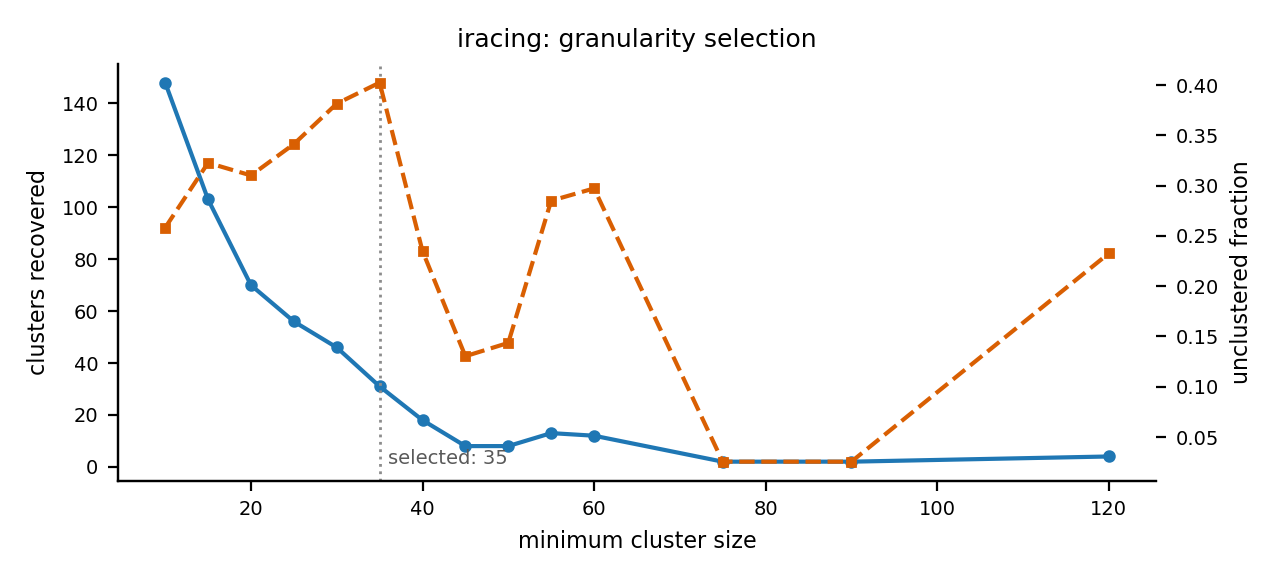

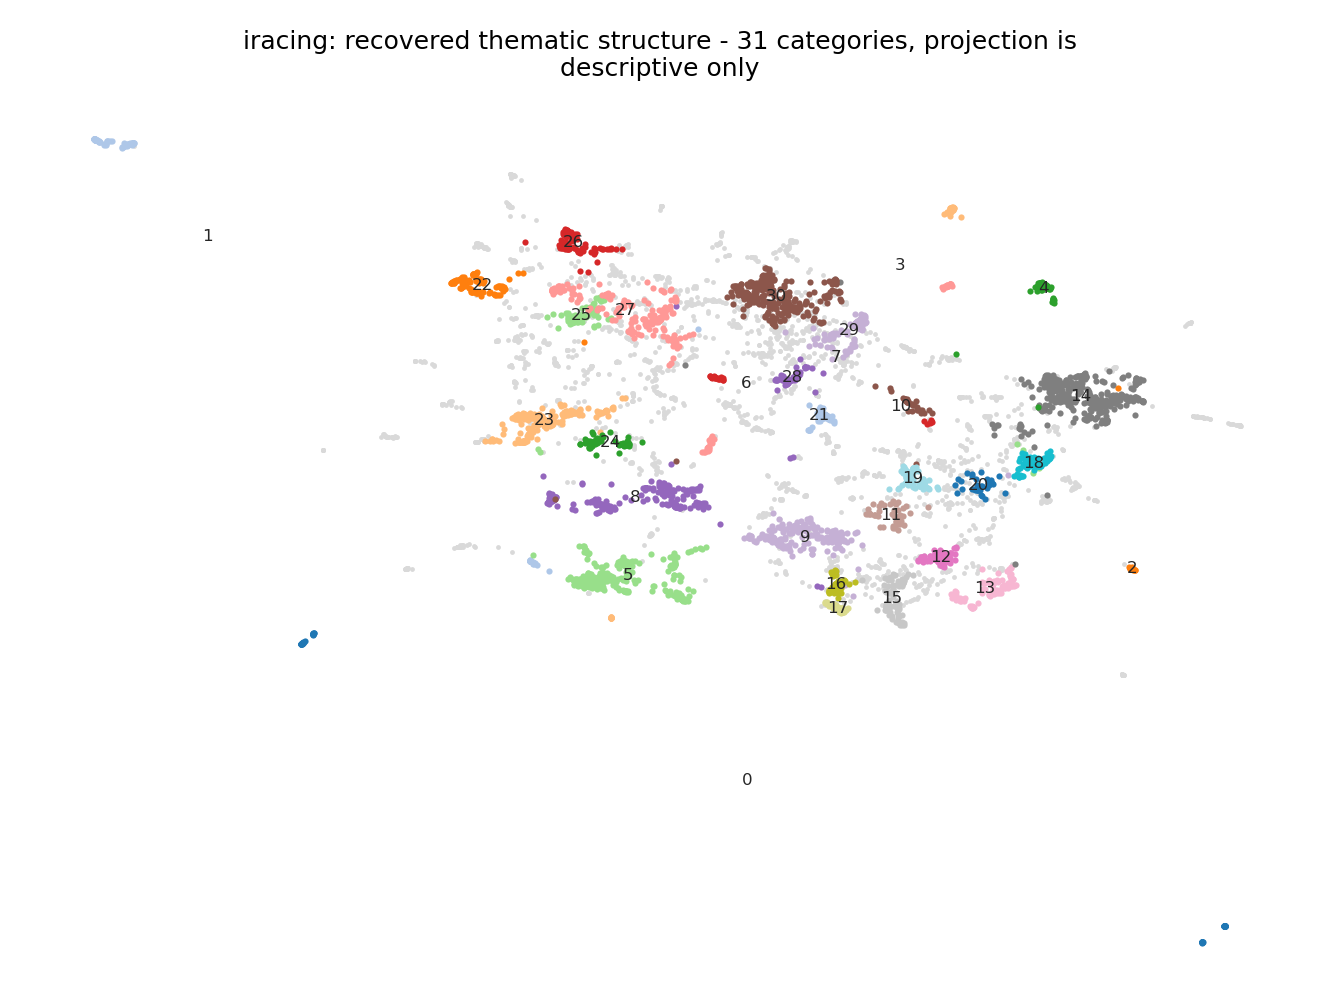

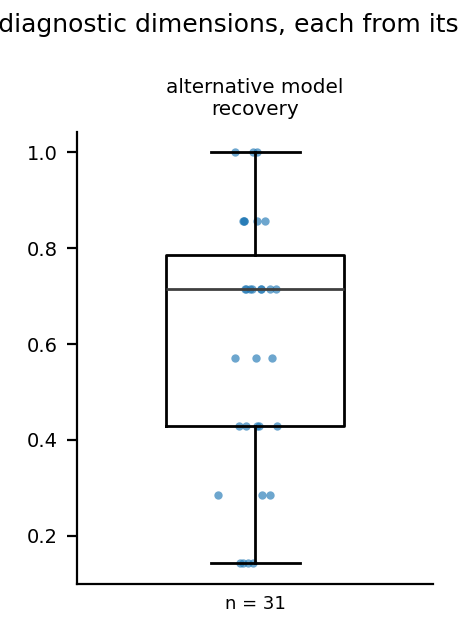

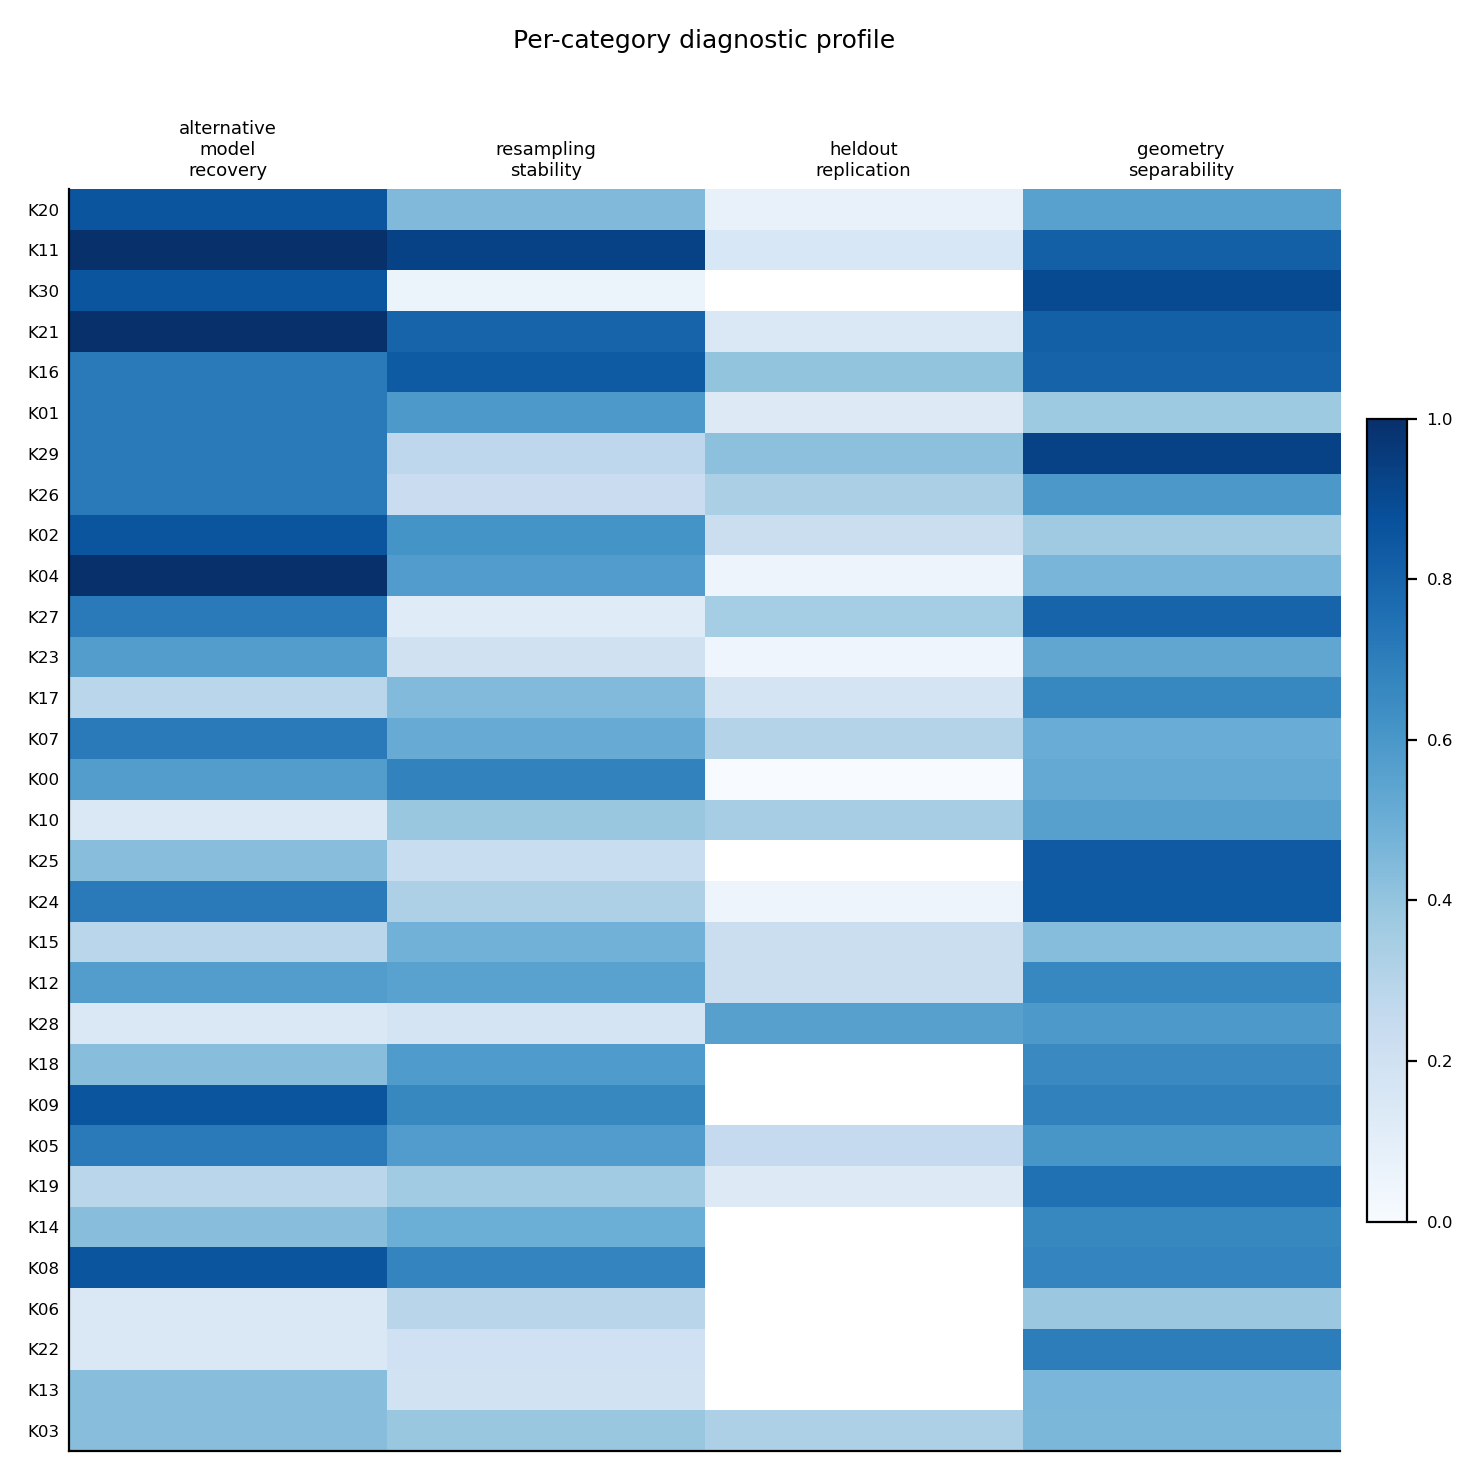

In [18]:
display_xy = P.clustering.descriptive_projection(cfg, X)

FIG = P.analytical_figures.write_all(
    REL, cfg, TAB, sweep, display_xy, labels,
    category_domains=CATEGORY_DOMAINS, ext=EXT, cfg2=cfg2, second=second,
    corr=corr, paired=paired, cross_register_figures=XR / "figures")

print(f"{len(FIG)} figures written")
for k in sorted(FIG):
    print(f"  {k:44s} {FIG[k]}")
for k in FIG:
    display(Image(filename=str(REL / FIG[k])))

## Stage 16 — Outputs

Everything this run wrote, by content name.

In [19]:
outputs = pd.DataFrame(
    [{"kind": "table", "name": k, "path": v} for k, v in sorted(TAB.items())]
    + [{"kind": "figure", "name": k, "path": v} for k, v in sorted(FIG.items())])
outputs.to_csv(Path(cfg.tables_dir) / "outputs.csv", index=False)
display(outputs)

,kind,name,path
0,table,alternative_model_recovery_per_category,results\iracing\tables\alternative_model_recov...
1,table,category_diagnostic_profiles,results\iracing\tables\category_diagnostic_pro...
2,table,category_inventory,results\iracing\tables\category_inventory.csv
3,table,category_lexical_enrichment_summary,results\iracing\tables\category_lexical_enrich...
4,table,category_lexical_signature_summary,results\iracing\tables\category_lexical_signat...
5,table,category_term_enrichment_records,results\iracing\tables\category_term_enrichmen...
6,table,corpus_roles_and_characteristics,results\iracing\tables\corpus_roles_and_charac...
7,table,corpus_summary,results\iracing\tables\corpus_summary.csv
8,table,diagnostic_run_summary,results\iracing\tables\diagnostic_run_summary.csv
9,table,geometry_separability_per_category,results\iracing\tables\geometry_separability_p...


## Stage 17 — Results of this run

The values below are the ones this execution computed. Nothing here is compared
against a stored result: the numbers are whatever the analyses produced.

In [20]:
P.reporting.run_summary(CONFIG, cfg, docs, labels, runtime=time.time() - T0,
                        ext=EXT, cfg2=cfg2, docs2=docs2, second=second,
                        corr=corr, paired=paired, tables=TAB, figures=FIG,
                        release_root=REL)

if "domain_membership" in EXT:
    print("\nSystematic leave-one-category-out")
    display(EXT["domain_membership"]["leave_one_category_out"][
        ["variant", "median_ilr_delta", "n_negative_ilr", "p_sign_ilr"]])
    print("Exploratory boundary reassignment")
    display(EXT["domain_membership"]["boundary_reassignment"][
        ["variant", "median_ilr_delta", "n_negative_ilr", "exploratory"]])

configuration   : iracing - redistributable one-register demonstration corpus
runtime         : 4s

Primary corpus
  events                8
  sentences             5,967
  categories            31
  clustered             3,565
  unclustered           2,402
  unclustered fraction  0.4025
  minimum cluster size  35

14 tables and 4 figures written under results\iracing
